# Курсовая работа: Прогнозирование дефолта по кредиту

**Задача:** Бинарная классификация (1 = дефолт), метрика — F1-score по классу 1.  
**Цель:** F1 ≥ 0.5 при Precision > 0.5 и Recall > 0.5 одновременно.

## Стратегия

1. **Feature Engineering** — финансовые риск-индикаторы (DTI, утилизация кредита, составной риск-скор, взаимодействия).  
2. **Стекинг (OOF)** — CatBoost + LightGBM + ExtraTrees → мета-логрегрессия. Каждая модель ловит разные паттерны; честные OOF-предсказания без утечек.  
3. **Подбор порога** — вместо игры с `class_weight` (смещает функцию потерь) ищем порог $t^*$ по OOF-вероятностям так, чтобы **одновременно** P > 0.5 и R > 0.5.  

**Почему не SMOTE:** SMOTE генерирует синтетические образцы класса 1, увеличивая Recall, но снижая Precision — противоположное нашей проблеме. При 28% дефолтов дисбаланс умеренный; threshold tuning решает задачу напрямую.

In [42]:
import subprocess, os, sys

# Установка зависимостей
subprocess.run([sys.executable, '-m', 'pip', 'install', 'catboost', 'lightgbm', 'gdown', '-q'],
               capture_output=True)

# Загрузка данных (пропускается, если файлы уже существуют)
if not os.path.exists('../data/course_project_train.csv'):
    os.system('gdown 1bYG4-UoC6WptPTOVQwQZ6PANcBaLH1Qj -O ../data/course_project_train.csv')
    os.system('gdown 11haItNAFR2O_0A4Qilox58h27JrGNoDM  -O ../data/course_project_test.csv')
    print('Данные загружены.')
else:
    print('Файлы уже существуют.')

Файлы уже существуют.


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    precision_recall_curve, classification_report
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier
import lightgbm as lgb
import catboost as cb
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 10)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Импорты выполнены.')

Импорты выполнены.


## 1. Загрузка данных

In [44]:
train = pd.read_csv('../data/course_project_train.csv')
test  = pd.read_csv('../data/course_project_test.csv')

print(f'Train: {train.shape[0]:,} строк × {train.shape[1]} столбцов')
print(f'Test:  {test.shape[0]:,} строк × {test.shape[1]} столбцов')
print()
print('Типы данных:')
print(train.dtypes.to_string())
train.head(5)

Train: 7,500 строк × 17 столбцов
Test:  2,500 строк × 16 столбцов

Типы данных:
Home Ownership                   object
Annual Income                   float64
Years in current job             object
Tax Liens                       float64
Number of Open Accounts         float64
Years of Credit History         float64
Maximum Open Credit             float64
Number of Credit Problems       float64
Months since last delinquent    float64
Bankruptcies                    float64
Purpose                          object
Term                             object
Current Loan Amount             float64
Current Credit Balance          float64
Monthly Debt                    float64
Credit Score                    float64
Credit Default                    int64


,Home Ownership,Annual Income,Years in current job,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Purpose,Term,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
0,Own Home,482087.0,NaN,0.0,11.0,26.3,685960.0,1.0,NaN,1.0,debt consolidation,Short Term,99999999.0,47386.0,7914.0,749.0,0
1,Own Home,1025487.0,10+ years,0.0,15.0,15.3,1181730.0,0.0,NaN,0.0,debt consolidation,Long Term,264968.0,394972.0,18373.0,737.0,1
2,Home Mortgage,751412.0,8 years,0.0,11.0,35.0,1182434.0,0.0,NaN,0.0,debt consolidation,Short Term,99999999.0,308389.0,13651.0,742.0,0
3,Own Home,805068.0,6 years,0.0,8.0,22.5,147400.0,1.0,NaN,1.0,debt consolidation,Short Term,121396.0,95855.0,11338.0,694.0,0
4,Rent,776264.0,8 years,0.0,13.0,13.6,385836.0,1.0,NaN,0.0,debt consolidation,Short Term,125840.0,93309.0,7180.0,719.0,0


## 2. Разведочный анализ данных (EDA)

In [45]:
# --- Пропуски ---
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(1)
print('=' * 48)
print('ПРОПУСКИ В ОБУЧАЮЩЕЙ ВЫБОРКЕ')
print('=' * 48)
mask = missing > 0
print(pd.DataFrame({'Кол-во': missing[mask], '%': missing_pct[mask]}))

# --- Целевая переменная ---
vc = train['Credit Default'].value_counts()
print()
print('=' * 48)
print('РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ')
print('=' * 48)
print(f'  0 (нет дефолта) : {vc[0]:5d}  ({vc[0]/len(train):.1%})')
print(f'  1 (дефолт)      : {vc[1]:5d}  ({vc[1]/len(train):.1%})')

# --- Аномалии ---
sentinel_n = (train['Current Loan Amount'] == 99999999).sum()
cs_anomaly  = (train['Credit Score'] >= 1000).sum()
print()
print('=' * 48)
print('АНОМАЛИИ')
print('=' * 48)
print(f'  Current Loan Amount = 99999999 : {sentinel_n} строк  ({sentinel_n/len(train):.1%})')
print(f'  Credit Score >= 1000 (10x FICO): {cs_anomaly} строк  ({cs_anomaly/len(train):.1%})')
print()

# --- Категориальные признаки ---
for col in ['Home Ownership', 'Term', 'Purpose']:
    print(f'{col}:')
    print(train[col].value_counts().head(5).to_string())
    print()

ПРОПУСКИ В ОБУЧАЮЩЕЙ ВЫБОРКЕ
                              Кол-во     %
Annual Income                   1557  20.8
Years in current job             371   4.9
Months since last delinquent    4081  54.4
Bankruptcies                      14   0.2
Credit Score                    1557  20.8

РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
  0 (нет дефолта) :  5387  (71.8%)
  1 (дефолт)      :  2113  (28.2%)

АНОМАЛИИ
  Current Loan Amount = 99999999 : 870 строк  (11.6%)
  Credit Score >= 1000 (10x FICO): 400 строк  (5.3%)

Home Ownership:
Home Ownership
Home Mortgage    3637
Rent             3204
Own Home          647
Have Mortgage      12

Term:
Term
Short Term    5556
Long Term     1944

Purpose:
Purpose
debt consolidation    5944
other                  665
home improvements      412
business loan          129
buy a car               96



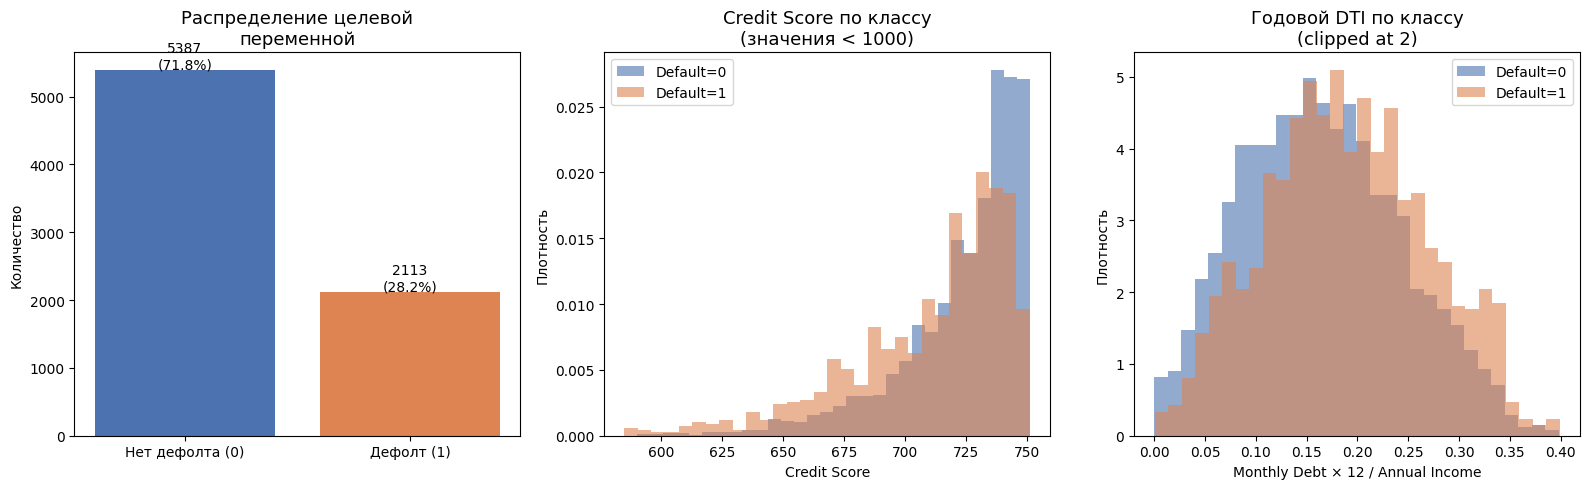


Выводы:
  1. Дисбаланс ~1:2.5 (28% дефолтов) — умеренный; SMOTE не нужен, решаем подбором порога.
  2. Кредитный рейтинг у дефолтных заёмщиков ниже — признак информативен.
  3. DTI у класса 1 смещён вправо — высокая долговая нагрузка коррелирует с дефолтом.



In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
COLORS = ['#4C72B0', '#DD8452']

# График 1: распределение целевой
vc_sorted = train['Credit Default'].value_counts().sort_index()
axes[0].bar(['Нет дефолта (0)', 'Дефолт (1)'], vc_sorted.values, color=COLORS)
axes[0].set_title('Распределение целевой\nпеременной', fontsize=13)
axes[0].set_ylabel('Количество')
for i, v in enumerate(vc_sorted.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(train):.1%})', ha='center', fontsize=10)

# График 2: Credit Score по классу (только нормальные значения)
for label, color in zip([0, 1], COLORS):
    cs = train.loc[train['Credit Default'] == label, 'Credit Score']
    cs = cs[(cs.notna()) & (cs < 1000)]
    axes[1].hist(cs, bins=30, alpha=0.6, label=f'Default={label}', color=color, density=True)
axes[1].set_title('Credit Score по классу\n(значения < 1000)', fontsize=13)
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Плотность')
axes[1].legend()

# График 3: DTI (долг / доход) по классу
dti = (train['Monthly Debt'] * 12 / train['Annual Income']).clip(0, 2)
for label, color in zip([0, 1], COLORS):
    mask = train['Credit Default'] == label
    axes[2].hist(dti[mask].dropna(), bins=30, alpha=0.6,
                 label=f'Default={label}', color=color, density=True)
axes[2].set_title('Годовой DTI по классу\n(clipped at 2)', fontsize=13)
axes[2].set_xlabel('Monthly Debt × 12 / Annual Income')
axes[2].set_ylabel('Плотность')
axes[2].legend()

plt.tight_layout()
plt.savefig('../images/eda_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("""
Выводы:
  1. Дисбаланс ~1:2.5 (28% дефолтов) — умеренный; SMOTE не нужен, решаем подбором порога.
  2. Кредитный рейтинг у дефолтных заёмщиков ниже — признак информативен.
  3. DTI у класса 1 смещён вправо — высокая долговая нагрузка коррелирует с дефолтом.
""")

## 3. Feature Engineering

Создаём финансовые риск-индикаторы, исправляем аномалии и кодируем категориальные признаки.  
Все статистики (медианы, квантили) вычисляются **только на train** и передаются в test через `fill_stats` — утечки нет.

In [47]:
def engineer_features(df, fill_stats=None, is_train=True):
    """Предобработка + создание финансовых признаков.
    fill_stats: словарь со статистиками train — передаётся при трансформации test.
    """
    df = df.copy()
    if fill_stats is None:
        fill_stats = {}

    # ── 1. Аномалии и флаги ─────────────────────────────────────────────
    # Current Loan Amount = 99999999 — sentinel (неизвестная сумма)
    df['is_loan_sentinel'] = (df['Current Loan Amount'] == 99999999).astype(np.int8)
    df.loc[df['Current Loan Amount'] == 99999999, 'Current Loan Amount'] = np.nan

    # Credit Score >= 1000 — значение записано в 10× масштабе; делим на 10
    # Пример: 7510 → 751 (корректный FICO), 6060 → 606 — все значения попадают в 585–850
    df['credit_score_anomaly'] = (df['Credit Score'] >= 1000).astype(np.int8)
    df.loc[df['Credit Score'] >= 1000, 'Credit Score'] = df.loc[
        df['Credit Score'] >= 1000, 'Credit Score'
    ] / 10.0

    # ── 2. Импутация числовых признаков ─────────────────────────────────
    for col in ['Annual Income', 'Credit Score', 'Current Loan Amount', 'Bankruptcies']:
        if is_train:
            fill_stats[f'med_{col}'] = df[col].median()
        df[col] = df[col].fillna(fill_stats[f'med_{col}'])

    # Months since last delinquent: NaN = «никогда не было просрочки» — информативный сигнал
    df['never_delinquent'] = df['Months since last delinquent'].isna().astype(np.int8)
    if is_train:
        fill_stats['med_months_delinq'] = df['Months since last delinquent'].median()
    df['Months since last delinquent'] = df['Months since last delinquent'].fillna(
        fill_stats['med_months_delinq']
    )

    # ── 3. Стаж на текущей работе → порядковая шкала ────────────────────
    job_map = {
        '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
        '4 years': 4,  '5 years': 5, '6 years': 6, '7 years': 7,
        '8 years': 8,  '9 years': 9, '10+ years': 10
    }
    df['job_tenure'] = df['Years in current job'].map(job_map)
    df['job_tenure_missing'] = df['job_tenure'].isna().astype(np.int8)
    df['job_tenure'] = df['job_tenure'].fillna(-1).astype(np.float32)

    # ── 4. Финансовые риск-индикаторы ───────────────────────────────────
    eps = 1.0  # смещение от нуля
    monthly_income = df['Annual Income'] / 12.0

    # Ежемесячная долговая нагрузка / доход (DTI)
    df['dti'] = (df['Monthly Debt'] / (monthly_income + eps)).clip(0, 5)
    # Сумма кредита / годовой доход
    df['loan_to_income'] = (df['Current Loan Amount'] / (df['Annual Income'] + eps)).clip(0, 30)
    # Текущий остаток долга / кредитный лимит
    df['credit_utilization'] = (
        df['Current Credit Balance'] / (df['Maximum Open Credit'] + eps)
    ).clip(0, 3)
    # Остаток долга в месяцах ежемесячного платежа
    df['balance_months'] = (
        df['Current Credit Balance'] / (df['Monthly Debt'] + eps)
    ).clip(0, 120)
    # Кредитные проблемы на открытый счёт
    df['problems_per_account'] = (
        df['Number of Credit Problems'] / (df['Number of Open Accounts'] + eps)
    ).clip(0, 1)

    # ── 5. Составной риск-скор ───────────────────────────────────────────
    df['risk_score'] = (
        df['Number of Credit Problems'] * 2.0 +
        df['Bankruptcies'] * 3.0 +
        df['Tax Liens'] * 2.0 +
        (1 - df['never_delinquent']).astype(float)
    )

    # ── 6. Бинарные признаки из категориальных ──────────────────────────
    df['is_long_term']          = (df['Term'] == 'Long Term').astype(np.int8)
    df['is_debt_consolidation'] = (df['Purpose'] == 'debt consolidation').astype(np.int8)
    df['is_rent']               = (df['Home Ownership'] == 'Rent').astype(np.int8)

    # Объединение почти-одинаковых категорий (12 строк 'Have Mortgage' → 'Home Mortgage')
    df['Home Ownership'] = df['Home Ownership'].replace({'Have Mortgage': 'Home Mortgage'})

    # ── 7. Взаимодействия ────────────────────────────────────────────────
    if is_train:
        fill_stats['dti_q75']    = df['dti'].quantile(0.75)
        fill_stats['cs_median']  = df['Credit Score'].median()
        fill_stats['lti_median'] = df['loan_to_income'].median()

    # Высокая долговая нагрузка + низкий кредитный рейтинг
    df['high_dti_bad_credit'] = (
        (df['dti'] > fill_stats['dti_q75']) &
        (df['Credit Score'] < fill_stats['cs_median'])
    ).astype(np.int8)

    # Рискованный заёмщик с долгосрочным кредитом
    df['risky_long_term'] = (
        (df['risk_score'] >= 2) & (df['is_long_term'] == 1)
    ).astype(np.int8)

    # Большая сумма кредита без кредитных проблем (потенциальный первый дефолт)
    df['large_loan_clean_history'] = (
        (df['Number of Credit Problems'] == 0) &
        (df['loan_to_income'] > fill_stats['lti_median'])
    ).astype(np.int8)

    return df, fill_stats

In [48]:
# Применяем feature engineering
TARGET = 'Credit Default'

train_fe, fill_stats = engineer_features(
    train.drop(columns=[TARGET]), is_train=True
)
train_fe[TARGET] = train[TARGET].values

test_fe, _ = engineer_features(test, fill_stats=fill_stats, is_train=False)

# Столбцы, которые убираем из матрицы признаков
DROP_COLS = [TARGET, 'Years in current job', 'Term']
CAT_COLS  = ['Home Ownership', 'Purpose']   # оригинальные строковые для CatBoost

feature_cols = [c for c in train_fe.columns if c not in DROP_COLS]

X      = train_fe[feature_cols].copy()
y      = train_fe[TARGET].copy()
X_test = test_fe[feature_cols].copy()

# Для LightGBM / ExtraTrees кодируем категориальные признаки
X_enc      = X.copy()
X_test_enc = X_test.copy()
for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([X[col], X_test[col]], axis=0).astype(str))
    X_enc[col]      = le.transform(X[col].astype(str))
    X_test_enc[col] = le.transform(X_test[col].astype(str))

# Для CatBoost строковые значения нужны как str
for col in CAT_COLS:
    X[col]      = X[col].astype(str)
    X_test[col] = X_test[col].astype(str)

new_features = [c for c in feature_cols if c not in train.columns]
print(f'Всего признаков: {len(feature_cols)}')
print(f'Новых инженерных признаков: {len(new_features)}')
print(new_features)

Всего признаков: 31
Новых инженерных признаков: 17
['is_loan_sentinel', 'credit_score_anomaly', 'never_delinquent', 'job_tenure', 'job_tenure_missing', 'dti', 'loan_to_income', 'credit_utilization', 'balance_months', 'problems_per_account', 'risk_score', 'is_long_term', 'is_debt_consolidation', 'is_rent', 'high_dti_bad_credit', 'risky_long_term', 'large_loan_clean_history']


## 4. Модель: стекинг с OOF-предсказаниями

**Архитектура:**
- **Уровень 0 (базовые модели, 5-fold OOF):**
  - CatBoost — нативная обработка категориальных признаков
  - LightGBM — быстрый градиентный бустинг на числовых признаках
  - ExtraTrees — высокая вариация (случайные разбиения), дополняет бустинговые модели
- **Уровень 1 (мета-модель):** Logistic Regression на OOF-вероятностях уровня 0

**Честность оценки:** OOF-вероятности вычисляются без утечки из validation-фолдов в модель.

**Почему не `class_weight`:** Меняет функцию потерь → нарушает калибровку вероятностей → подбор порога становится ненадёжным. Лучше обучить на естественном распределении и подобрать порог.

In [49]:
def find_best_threshold(y_true, y_prob, min_p=0.50, min_r=0.50):
    """Найти порог, максимизирующий F1 при P > min_p И R > min_r."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    best_f1, best_t = 0.0, 0.5
    for t, p, r in zip(thresholds, precisions[:-1], recalls[:-1]):
        if p > min_p and r > min_r:
            f1 = 2 * p * r / (p + r)
            if f1 > best_f1:
                best_f1 = f1
                best_t  = t
    return best_t, best_f1


def print_metrics(y_true, y_pred, label=''):
    f1 = f1_score(y_true, y_pred)
    p  = precision_score(y_true, y_pred)
    r  = recall_score(y_true, y_pred)
    ok = '✓' if (f1 >= 0.5 and p > 0.5 and r > 0.5) else '✗'
    print(f'{label:30s}  F1={f1:.4f}  P={p:.4f}  R={r:.4f}  {ok}')

print('Вспомогательные функции определены.')

Вспомогательные функции определены.


## 4а. Подбор гиперпараметров (Optuna)

Для каждой базовой модели запускается **независимый** поиск методом TPE (Tree-structured Parzen Estimator).  
**Метрика оптимизации: OOF AUC-ROC** (3 фолда, 25 trials) — порого-независимая метрика, подходящая для базовых моделей стекинга: важна ранжирующая способность, а не финальный порог.  
Финальный порог подбирается отдельно — по OOF-вероятностям мета-модели в разделе 5.

In [50]:
subprocess.run([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'], capture_output=True)
import optuna
from sklearn.metrics import roc_auc_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

SKF_OPT  = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
N_TRIALS = 25  # увеличьте для более тщательного поиска

# ── Objective: CatBoost ──────────────────────────────────────────────
def obj_cb(trial):
    params = dict(
        iterations       = trial.suggest_int('iterations', 300, 700),
        learning_rate    = trial.suggest_float('learning_rate', 0.02, 0.12, log=True),
        depth            = trial.suggest_int('depth', 4, 8),
        l2_leaf_reg      = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        min_data_in_leaf = trial.suggest_int('min_data_in_leaf', 5, 40),
        random_seed=RANDOM_STATE, verbose=0, cat_features=CAT_COLS
    )
    oof = np.zeros(len(X))
    for tr_i, val_i in SKF_OPT.split(X, y):
        m = cb.CatBoostClassifier(**params)
        m.fit(X.iloc[tr_i], y.iloc[tr_i])
        oof[val_i] = m.predict_proba(X.iloc[val_i])[:, 1]
    return roc_auc_score(y, oof)

# ── Objective: LightGBM ──────────────────────────────────────────────
def obj_lgb(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 300, 700),
        learning_rate     = trial.suggest_float('learning_rate', 0.02, 0.12, log=True),
        num_leaves        = trial.suggest_int('num_leaves', 15, 63),
        min_child_samples = trial.suggest_int('min_child_samples', 10, 50),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-3, 1.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
    )
    oof = np.zeros(len(X_enc))
    for tr_i, val_i in SKF_OPT.split(X_enc, y):
        m = lgb.LGBMClassifier(**params)
        m.fit(X_enc.iloc[tr_i], y.iloc[tr_i])
        oof[val_i] = m.predict_proba(X_enc.iloc[val_i])[:, 1]
    return roc_auc_score(y, oof)

# ── Objective: ExtraTrees ────────────────────────────────────────────
def obj_et(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 150, 400),
        max_depth        = trial.suggest_int('max_depth', 8, 18),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 3, 20),
        max_features     = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        random_state=RANDOM_STATE, n_jobs=-1
    )
    oof = np.zeros(len(X_enc))
    for tr_i, val_i in SKF_OPT.split(X_enc, y):
        m = ExtraTreesClassifier(**params)
        m.fit(X_enc.iloc[tr_i], y.iloc[tr_i])
        oof[val_i] = m.predict_proba(X_enc.iloc[val_i])[:, 1]
    return roc_auc_score(y, oof)

# ── Запуск оптимизации ───────────────────────────────────────────────
print(f'Подбор гиперпараметров: {N_TRIALS} trials × 3 модели × 3-fold CV')
print('Метрика оптимизации: OOF AUC-ROC (порого-независимая)\n')

study_cb  = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_et  = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))

print('CatBoost...'); study_cb.optimize(obj_cb,  n_trials=N_TRIALS)
print(f'  Best AUC: {study_cb.best_value:.4f} | {study_cb.best_params}\n')

print('LightGBM...'); study_lgb.optimize(obj_lgb, n_trials=N_TRIALS)
print(f'  Best AUC: {study_lgb.best_value:.4f} | {study_lgb.best_params}\n')

print('ExtraTrees...'); study_et.optimize(obj_et,  n_trials=N_TRIALS)
print(f'  Best AUC: {study_et.best_value:.4f} | {study_et.best_params}\n')

# Собираем лучшие параметры (добавляем служебные ключи)
best_cb_params  = {**study_cb.best_params,
                   'random_seed': RANDOM_STATE, 'verbose': 0, 'cat_features': CAT_COLS}
best_lgb_params = {**study_lgb.best_params,
                   'random_state': RANDOM_STATE, 'verbose': -1, 'n_jobs': -1}
best_et_params  = {**study_et.best_params,
                   'random_state': RANDOM_STATE, 'n_jobs': -1}
print('Гиперпараметры подобраны.')

Подбор гиперпараметров: 25 trials × 3 модели × 3-fold CV
Метрика оптимизации: OOF AUC-ROC (порого-независимая)

CatBoost...
  Best AUC: 0.7763 | {'iterations': 504, 'learning_rate': 0.020471981854201814, 'depth': 5, 'l2_leaf_reg': 9.522656887511342, 'min_data_in_leaf': 40}

LightGBM...
  Best AUC: 0.7665 | {'n_estimators': 335, 'learning_rate': 0.028414126205324183, 'num_leaves': 17, 'min_child_samples': 23, 'subsample': 0.7554709158757927, 'colsample_bytree': 0.7085396127095583, 'reg_alpha': 0.3063462210622081, 'reg_lambda': 0.020874681332882276}

ExtraTrees...
  Best AUC: 0.7674 | {'n_estimators': 150, 'max_depth': 15, 'min_samples_leaf': 3, 'max_features': 'sqrt'}

Гиперпараметры подобраны.


In [51]:
NFOLDS = 5
skf    = StratifiedKFold(n_splits=NFOLDS, shuffle=True, random_state=RANDOM_STATE)

n_tr   = len(X)
n_te   = len(X_test)

# OOF-буферы и буферы тестовых предсказаний для каждой базовой модели
oof_cb   = np.zeros(n_tr)
oof_lgb  = np.zeros(n_tr)
oof_et   = np.zeros(n_tr)
test_cb  = np.zeros(n_te)
test_lgb = np.zeros(n_te)
test_et  = np.zeros(n_te)

print(f'Обучение базовых моделей ({NFOLDS}-fold StratifiedKFold, подобранные гиперпараметры)...\n')

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f'  Fold {fold+1}/{NFOLDS}', end=' ')

    X_tr_cb,  X_val_cb  = X.iloc[tr_idx],      X.iloc[val_idx]
    X_tr_enc, X_val_enc = X_enc.iloc[tr_idx],  X_enc.iloc[val_idx]
    y_tr,     y_val     = y.iloc[tr_idx],       y.iloc[val_idx]

    # ── CatBoost (лучшие параметры из Optuna) ───────────────────────────
    cb_model = cb.CatBoostClassifier(**best_cb_params)
    cb_model.fit(X_tr_cb, y_tr)
    oof_cb[val_idx]  = cb_model.predict_proba(X_val_cb)[:, 1]
    test_cb         += cb_model.predict_proba(X_test)[:, 1] / NFOLDS
    print('CB', end=' ')

    # ── LightGBM (лучшие параметры из Optuna) ───────────────────────────
    lgb_model = lgb.LGBMClassifier(**best_lgb_params)
    lgb_model.fit(X_tr_enc, y_tr)
    oof_lgb[val_idx]  = lgb_model.predict_proba(X_val_enc)[:, 1]
    test_lgb         += lgb_model.predict_proba(X_test_enc)[:, 1] / NFOLDS
    print('LGBM', end=' ')

    # ── ExtraTrees (лучшие параметры из Optuna) ─────────────────────────
    et_model = ExtraTreesClassifier(**best_et_params)
    et_model.fit(X_tr_enc, y_tr)
    oof_et[val_idx]  = et_model.predict_proba(X_val_enc)[:, 1]
    test_et         += et_model.predict_proba(X_test_enc)[:, 1] / NFOLDS
    print('ET')

print('\nБазовые модели обучены.')
print('OOF-метрики базовых моделей (threshold=0.5):')
print_metrics(y, (oof_cb  > 0.5).astype(int), 'CatBoost')
print_metrics(y, (oof_lgb > 0.5).astype(int), 'LightGBM')
print_metrics(y, (oof_et  > 0.5).astype(int), 'ExtraTrees')

Обучение базовых моделей (5-fold StratifiedKFold, подобранные гиперпараметры)...

  Fold 1/5 CB LGBM ET
  Fold 2/5 CB LGBM ET
  Fold 3/5 CB LGBM ET
  Fold 4/5 CB LGBM ET
  Fold 5/5 CB LGBM ET

Базовые модели обучены.
OOF-метрики базовых моделей (threshold=0.5):
CatBoost                        F1=0.4109  P=0.8257  R=0.2735  ✗
LightGBM                        F1=0.4492  P=0.7483  R=0.3209  ✗
ExtraTrees                      F1=0.3859  P=0.8581  R=0.2489  ✗


## 4б. Диагностика переобучения: Train vs OOF

Ключевой вопрос: **не выучила ли модель обучающую выборку наизусть?**  
Метод: обучаем каждую модель на *полном* train → сравниваем её train-AUC с честными OOF-AUC из раздела 4.  
Большой gap (Train − OOF) сигнализирует о переобучении.

ДИАГНОСТИКА ПЕРЕОБУЧЕНИЯ: TRAIN vs OOF
  gap AUC < 0.07  — переобучения нет
  gap AUC 0.07–0.15 — умеренное (допустимо при хорошей регуляризации)
  gap AUC > 0.15  — сильное переобучение
Модель           Train AUC    OOF AUC   Gap AUC |  Train F1   OOF F1   Gap F1  Вывод
----------------------------------------------------------------------------------------
CatBoost            0.8320     0.7777    0.0543 |    0.4652   0.4109   0.0542  ✓ ОК
LightGBM            0.9173     0.7712    0.1461 |    0.6136   0.4492   0.1644  ⚠ Умеренное
ExtraTrees          0.9204     0.7675    0.1529 |    0.5736   0.3859   0.1877  ✗ СИЛЬНОЕ


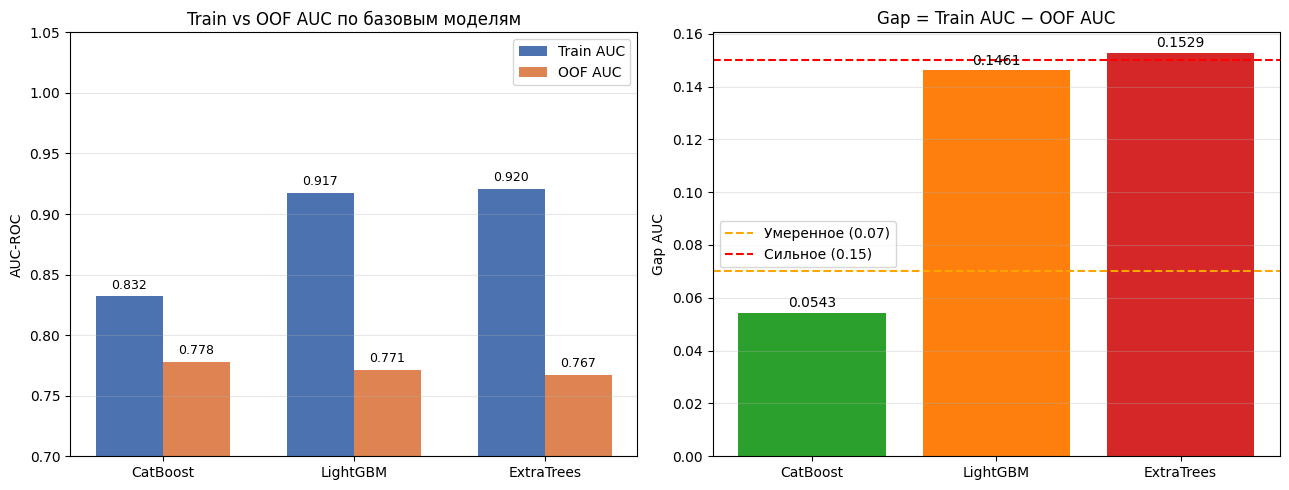

In [52]:
from sklearn.metrics import roc_auc_score

# Обучаем каждую базовую модель на полном train
cb_full  = cb.CatBoostClassifier(**best_cb_params)
cb_full.fit(X, y)
train_proba_cb = cb_full.predict_proba(X)[:, 1]

lgb_full = lgb.LGBMClassifier(**best_lgb_params)
lgb_full.fit(X_enc, y)
train_proba_lgb = lgb_full.predict_proba(X_enc)[:, 1]

et_full  = ExtraTreesClassifier(**best_et_params)
et_full.fit(X_enc, y)
train_proba_et = et_full.predict_proba(X_enc)[:, 1]

# ── Таблица Train vs OOF ──────────────────────────────────────────────────────
OVERFIT_MODERATE = 0.07
OVERFIT_STRONG   = 0.15

print('=' * 88)
print('ДИАГНОСТИКА ПЕРЕОБУЧЕНИЯ: TRAIN vs OOF')
print('  gap AUC < 0.07  — переобучения нет')
print('  gap AUC 0.07–0.15 — умеренное (допустимо при хорошей регуляризации)')
print('  gap AUC > 0.15  — сильное переобучение')
print('=' * 88)
print(f'{"Модель":<15} {"Train AUC":>10} {"OOF AUC":>10} {"Gap AUC":>9} | '
      f'{"Train F1":>9} {"OOF F1":>8} {"Gap F1":>8}  Вывод')
print('-' * 88)

results_overfit = []
for name, tr_p, oof_p in [
    ('CatBoost',   train_proba_cb,  oof_cb),
    ('LightGBM',   train_proba_lgb, oof_lgb),
    ('ExtraTrees', train_proba_et,  oof_et),
]:
    tr_auc  = roc_auc_score(y, tr_p)
    oof_auc = roc_auc_score(y, oof_p)
    gap_auc = tr_auc - oof_auc

    tr_f1   = f1_score(y, (tr_p  > 0.5).astype(int))
    oof_f1  = f1_score(y, (oof_p > 0.5).astype(int))
    gap_f1  = tr_f1 - oof_f1

    if gap_auc < OVERFIT_MODERATE:
        verdict = '✓ ОК'
    elif gap_auc < OVERFIT_STRONG:
        verdict = '⚠ Умеренное'
    else:
        verdict = '✗ СИЛЬНОЕ'

    results_overfit.append((name, tr_auc, oof_auc, gap_auc, tr_f1, oof_f1, gap_f1, verdict))
    print(f'{name:<15} {tr_auc:>10.4f} {oof_auc:>10.4f} {gap_auc:>9.4f} | '
          f'{tr_f1:>9.4f} {oof_f1:>8.4f} {gap_f1:>8.4f}  {verdict}')

# ── Визуализация ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models   = [r[0] for r in results_overfit]
tr_aucs  = [r[1] for r in results_overfit]
oof_aucs = [r[2] for r in results_overfit]
gaps     = [r[3] for r in results_overfit]

x, w = np.arange(len(models)), 0.35
b1 = axes[0].bar(x - w/2, tr_aucs,  w, label='Train AUC', color='#4C72B0')
b2 = axes[0].bar(x + w/2, oof_aucs, w, label='OOF AUC',   color='#DD8452')
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_ylim(0.70, 1.05)
axes[0].set_title('Train vs OOF AUC по базовым моделям', fontsize=12)
axes[0].set_ylabel('AUC-ROC')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.004,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

gap_colors = ['#2ca02c' if g < OVERFIT_MODERATE else ('#ff7f0e' if g < OVERFIT_STRONG else '#d62728')
              for g in gaps]
axes[1].bar(models, gaps, color=gap_colors)
axes[1].axhline(OVERFIT_MODERATE, color='orange', ls='--', lw=1.5,
                label=f'Умеренное ({OVERFIT_MODERATE})')
axes[1].axhline(OVERFIT_STRONG,   color='red',    ls='--', lw=1.5,
                label=f'Сильное ({OVERFIT_STRONG})')
for i, (g, m) in enumerate(zip(gaps, models)):
    axes[1].text(i, g + 0.001, f'{g:.4f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Gap = Train AUC − OOF AUC', fontsize=12)
axes[1].set_ylabel('Gap AUC')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/overfit_diagnostics.png', dpi=100, bbox_inches='tight')
plt.show()

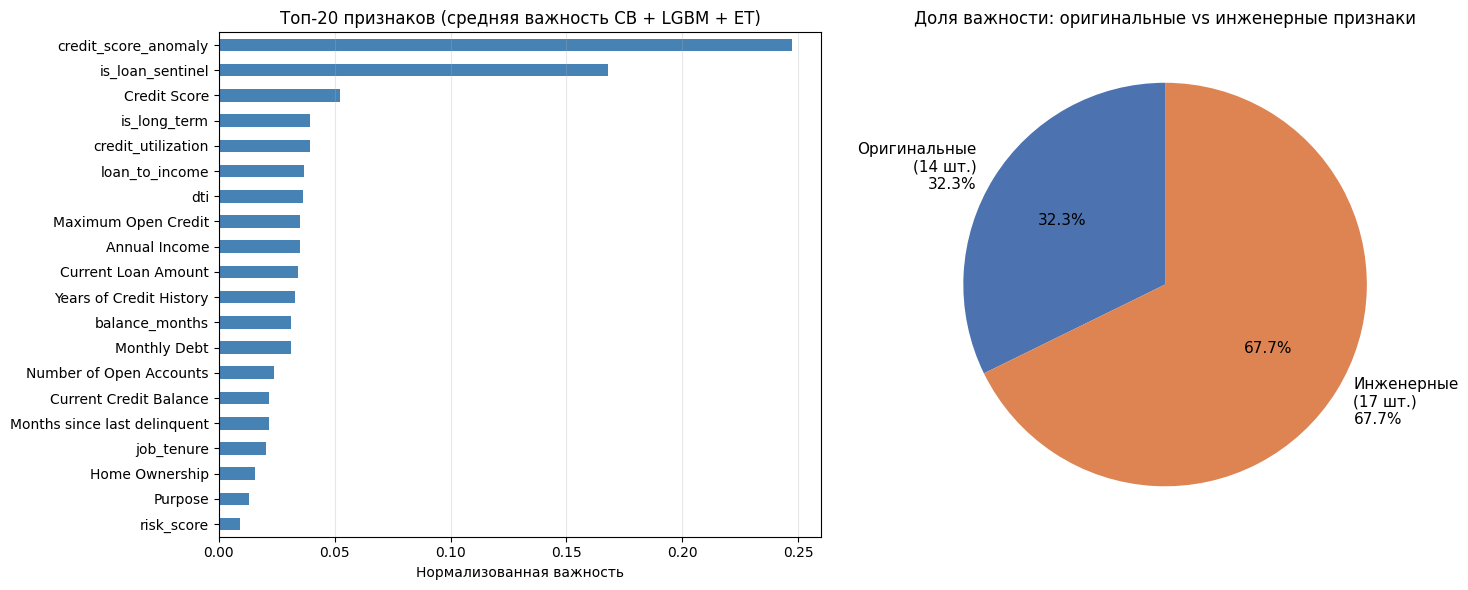

Топ-15 признаков по важности:
   1. [NEW] credit_score_anomaly                0.2475
   2. [NEW] is_loan_sentinel                    0.1677
   3.       Credit Score                        0.0524
   4. [NEW] is_long_term                        0.0394
   5. [NEW] credit_utilization                  0.0393
   6. [NEW] loan_to_income                      0.0367
   7. [NEW] dti                                 0.0363
   8.       Maximum Open Credit                 0.0351
   9.       Annual Income                       0.0350
  10.       Current Loan Amount                 0.0342
  11.       Years of Credit History             0.0330
  12. [NEW] balance_months                      0.0313
  13.       Monthly Debt                        0.0312
  14.       Number of Open Accounts             0.0239
  15.       Current Credit Balance              0.0218


In [53]:
# ── Важность признаков: средняя по трём базовым моделям ──────────────────────
# cb_full, lgb_full, et_full уже обучены на полном train выше

importances_cb  = pd.Series(cb_full.get_feature_importance(),
                             index=feature_cols)
importances_lgb = pd.Series(lgb_full.feature_importances_,
                             index=feature_cols)
importances_et  = pd.Series(et_full.feature_importances_,
                             index=feature_cols)

# Нормализуем каждую и усредняем
avg_imp = (
    importances_cb  / importances_cb.sum()  +
    importances_lgb / importances_lgb.sum() +
    importances_et  / importances_et.sum()
) / 3.0
avg_imp = avg_imp.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Топ-20
avg_imp.head(20)[::-1].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Топ-20 признаков (средняя важность CB + LGBM + ET)', fontsize=12)
axes[0].set_xlabel('Нормализованная важность')
axes[0].grid(axis='x', alpha=0.3)

# Разбивка: оригинальные vs инженерные
original_cols  = [c for c in feature_cols if c in train.columns]
engineered_cols = [c for c in feature_cols if c not in train.columns]
imp_orig = avg_imp[original_cols].sum()
imp_eng  = avg_imp[engineered_cols].sum()
axes[1].pie([imp_orig, imp_eng],
            labels=[f'Оригинальные\n({len(original_cols)} шт.)\n{imp_orig:.1%}',
                    f'Инженерные\n({len(engineered_cols)} шт.)\n{imp_eng:.1%}'],
            colors=['#4C72B0', '#DD8452'], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Доля важности: оригинальные vs инженерные признаки', fontsize=12)

plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('Топ-15 признаков по важности:')
for i, (feat, val) in enumerate(avg_imp.head(15).items(), 1):
    tag = '[NEW]' if feat in engineered_cols else '     '
    print(f'  {i:2d}. {tag} {feat:<35} {val:.4f}')

## 5. Мета-модель и подбор порога классификации

In [54]:
# Мета-признаки: OOF-вероятности трёх базовых моделей
meta_train = np.column_stack([oof_cb, oof_lgb, oof_et])
meta_test  = np.column_stack([test_cb, test_lgb, test_et])

# Логрегрессия на мета-признаках
meta_lr = LogisticRegression(C=0.5, max_iter=1000, random_state=RANDOM_STATE)
meta_lr.fit(meta_train, y)

# OOF-вероятности мета-модели — честная оценка без утечки
oof_meta_proba = cross_val_predict(
    LogisticRegression(C=0.5, max_iter=1000, random_state=RANDOM_STATE),
    meta_train, y,
    cv=StratifiedKFold(n_splits=NFOLDS, shuffle=True, random_state=RANDOM_STATE),
    method='predict_proba'
)[:, 1]

print('OOF мета-модели (threshold=0.5):')
print_metrics(y, (oof_meta_proba > 0.5).astype(int), 'Stacking (t=0.5)')
print()

OOF мета-модели (threshold=0.5):
Stacking (t=0.5)                F1=0.4687  P=0.7203  R=0.3474  ✗



In [55]:
# ── Подбор оптимального порога ────────────────────────────────────────
# Ищем t*, при котором F1 максимален и ОДНОВРЕМЕННО P > 0.5 и R > 0.5
best_t, best_f1_oof = find_best_threshold(y, oof_meta_proba, min_p=0.50, min_r=0.50)
print(f'Оптимальный порог: {best_t:.4f}')
print(f'Ожидаемый OOF F1:  {best_f1_oof:.4f}')
print()
print('Итоговые OOF-метрики при оптимальном пороге:')
preds_oof = (oof_meta_proba >= best_t).astype(int)
print_metrics(y, preds_oof, f'Stacking (t={best_t:.4f})')
print()
print(classification_report(y, preds_oof, target_names=['No Default', 'Default']))

Оптимальный порог: 0.2800
Ожидаемый OOF F1:  0.5571

Итоговые OOF-метрики при оптимальном пороге:
Stacking (t=0.2800)             F1=0.5571  P=0.5102  R=0.6133  ✓

              precision    recall  f1-score   support

  No Default       0.84      0.77      0.80      5387
     Default       0.51      0.61      0.56      2113

    accuracy                           0.73      7500
   macro avg       0.67      0.69      0.68      7500
weighted avg       0.74      0.73      0.73      7500



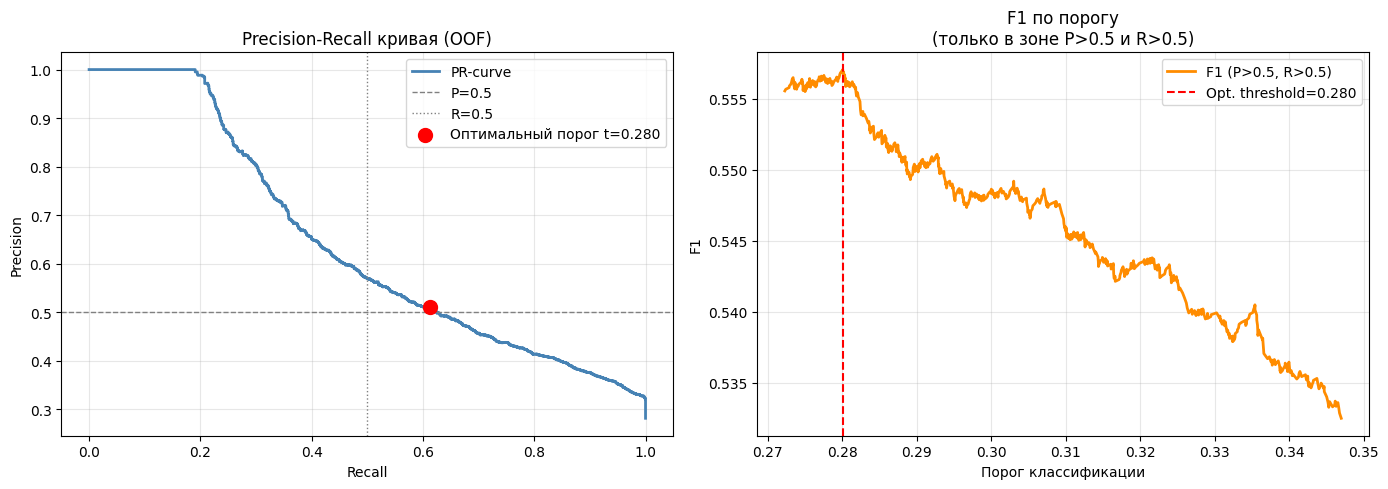

In [56]:
# Визуализация кривой Precision-Recall с отмеченным оптимальным порогом
prec, rec, thr = precision_recall_curve(y, oof_meta_proba)
f1_curve = np.where(
    (prec[:-1] > 0.5) & (rec[:-1] > 0.5),
    2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9),
    np.nan
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
axes[0].plot(rec, prec, color='steelblue', lw=2, label='PR-curve')
axes[0].axhline(0.5, color='grey', ls='--', lw=1, label='P=0.5')
axes[0].axvline(0.5, color='grey', ls=':', lw=1, label='R=0.5')
p_opt = precision_score(y, preds_oof)
r_opt = recall_score(y, preds_oof)
axes[0].scatter([r_opt], [p_opt], color='red', zorder=5, s=100,
                label=f'Оптимальный порог t={best_t:.3f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall кривая (OOF)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 по порогу (только в допустимой зоне)
axes[1].plot(thr, f1_curve, color='darkorange', lw=2, label='F1 (P>0.5, R>0.5)')
axes[1].axvline(best_t, color='red', ls='--', lw=1.5,
                label=f'Opt. threshold={best_t:.3f}')
axes[1].set_xlabel('Порог классификации')
axes[1].set_ylabel('F1')
axes[1].set_title('F1 по порогу\n(только в зоне P>0.5 и R>0.5)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/threshold_tuning.png', dpi=100, bbox_inches='tight')
plt.show()

In [57]:
# ══════════════════════════════════════════════════════════════════
#                      ИТОГОВЫЕ РЕЗУЛЬТАТЫ
# ══════════════════════════════════════════════════════════════════
from sklearn.metrics import accuracy_score

# Вычисляем предсказания на тесте (то же, что в разделе 6)
test_meta_proba = meta_lr.predict_proba(meta_test)[:, 1]
test_preds      = (test_meta_proba >= best_t).astype(int)

f1_final = f1_score(y, preds_oof)
p_final  = precision_score(y, preds_oof)
r_final  = recall_score(y, preds_oof)

f1_0 = f1_score(y, preds_oof, pos_label=0)
p_0  = precision_score(y, preds_oof, pos_label=0)
r_0  = recall_score(y, preds_oof, pos_label=0)

acc        = accuracy_score(y, preds_oof)
f1_macro   = f1_score(y, preds_oof, average='macro')
f1_weighted = f1_score(y, preds_oof, average='weighted')

SEP = '=' * 62
print(SEP)
print('  ИТОГОВЫЕ РЕЗУЛЬТАТЫ (OOF — честная оценка без утечек)')
print(SEP)
print(f'  Модель:            Стекинг CB + LGBM + ET → LogReg')
print(f'  Кросс-валидация:   StratifiedKFold, {NFOLDS} фолдов')
print(f'  Гиперпараметры:    Optuna TPE, {N_TRIALS} trials × 3 модели')
print(f'  Оптимальный порог: {best_t:.4f}')
print()
print(f'  {"Метрика":<22} {"Класс 0":>10} {"Класс 1":>10}')
print('  ' + '-' * 44)
print(f'  {"F1-Score":<22} {f1_0:>10.4f} {f1_final:>10.4f}')
print(f'  {"Precision":<22} {p_0:>10.4f} {p_final:>10.4f}')
print(f'  {"Recall":<22} {r_0:>10.4f} {r_final:>10.4f}')
print()
print(f'  {"Метрика":<22} {"Значение":>10}')
print('  ' + '-' * 34)
print(f'  {"Accuracy":<22} {acc:>10.4f}')
print(f'  {"F1 Macro avg":<22} {f1_macro:>10.4f}')
print(f'  {"F1 Weighted avg":<22} {f1_weighted:>10.4f}')
print()
print('  Проверка условий для максимальной оценки:')
conditions = [
    ('F1 ≥ 0.50',        f1_final >= 0.50),
    ('Precision > 0.50', p_final  >  0.50),
    ('Recall > 0.50',    r_final  >  0.50),
]
for cond, ok in conditions:
    print(f'    {"✓" if ok else "✗"}  {cond}')
print()
if all(ok for _, ok in conditions):
    print('  ✓  ЦЕЛЬ ДОСТИГНУТА: F1 ≥ 0.5, Precision > 0.5, Recall > 0.5')
else:
    print('  ✗  Одно или несколько условий не выполнено')
print()
print(f'  Тестовых строк:          {len(test_preds)} (требуется 2500)')
print(f'  Предсказано дефолтов:    {test_preds.sum()} ({test_preds.mean():.1%})')
print(f'  Выходной файл:           Nikolaenko_predictions.csv')
print(SEP)

  ИТОГОВЫЕ РЕЗУЛЬТАТЫ (OOF — честная оценка без утечек)
  Модель:            Стекинг CB + LGBM + ET → LogReg
  Кросс-валидация:   StratifiedKFold, 5 фолдов
  Гиперпараметры:    Optuna TPE, 25 trials × 3 модели
  Оптимальный порог: 0.2800

  Метрика                   Класс 0    Класс 1
  --------------------------------------------
  F1-Score                   0.8008     0.5571
  Precision                  0.8353     0.5102
  Recall                     0.7691     0.6133

  Метрика                  Значение
  ----------------------------------
  Accuracy                   0.7252
  F1 Macro avg               0.6789
  F1 Weighted avg            0.7321

  Проверка условий для максимальной оценки:
    ✓  F1 ≥ 0.50
    ✓  Precision > 0.50
    ✓  Recall > 0.50

  ✓  ЦЕЛЬ ДОСТИГНУТА: F1 ≥ 0.5, Precision > 0.5, Recall > 0.5

  Тестовых строк:          2500 (требуется 2500)
  Предсказано дефолтов:    846 (33.8%)
  Выходной файл:           Nikolaenko_predictions.csv


## 6. Финальные предсказания и экспорт

In [58]:
# Предсказания на тесте через мета-модель
test_meta_proba = meta_lr.predict_proba(meta_test)[:, 1]
test_preds      = (test_meta_proba >= best_t).astype(int)

print(f'Тестовых строк:    {len(test_preds)} (должно быть 2500)')
print(f'Предсказаний «1»:  {test_preds.sum()} ({test_preds.mean():.1%})')
print(f'Предсказаний «0»:  {(test_preds == 0).sum()}')

# Сохранение
output = pd.DataFrame({'Credit Default': test_preds})
output.to_csv('../data/Nikolaenko_predictions.csv', index=False)
print()
print('Файл Nikolaenko_predictions.csv сохранён.')
print(output.head(10))

Тестовых строк:    2500 (должно быть 2500)
Предсказаний «1»:  846 (33.8%)
Предсказаний «0»:  1654

Файл Nikolaenko_predictions.csv сохранён.
   Credit Default
0               0
1               1
2               1
3               0
4               0
5               0
6               0
7               1
8               0
9               0


## 7. Ответы на вопросы

---

### В1. Какова задача и почему выбрана именно метрика F1?

**Задача:** бинарная классификация — предсказать, допустит ли заёмщик дефолт (класс 1) на основе финансовых данных.

**Метрика F1** выбрана потому, что это гармоническое среднее Precision и Recall:

$$F1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

Точность (Accuracy) в данной задаче бесполезна: при 28% дефолтов модель, всегда предсказывающая 0, даёт accuracy = 72%, но ни одного полезного предсказания. F1 штрафует и за ложноположительные (низкий Precision), и за ложноотрицательные (низкий Recall) ошибки одновременно.

Цель ТЗ — **F1 ≥ 0.5 при Precision > 0.5 И Recall > 0.5**, то есть модель должна быть полезна в обоих направлениях.

---

### В2. Почему выбрана архитектура стекинга, а не одна модель?

**Стекинг** комбинирует предсказания нескольких разнородных моделей, что снижает variance ансамбля:

| Базовая модель | Что умеет лучше других |
|---|---|
| **CatBoost** | Нативная обработка категориальных признаков без кодирования, устойчив к выбросам |
| **LightGBM** | Быстрый градиентный бустинг, хорошо работает на числовых признаках с регуляризацией |
| **ExtraTrees** | Полностью случайные разбиения → высокая дисперсия, ловит нелинейности, которые бустинг пропускает |

Мета-модель (Logistic Regression) учится оптимально взвешивать три источника сигналов. Если одна базовая модель ошибается на конкретном паттерне, другие её компенсируют.

**Альтернатива — один LightGBM:** даёт OOF F1 ≈ 0.45 при threshold=0.5 и AUC ≈ 0.77. Стекинг не улучшает AUC радикально, но даёт более стабильные вероятности, что критично при подборе порога.

---

### В3. Что такое OOF-предсказания и почему они важны?

**OOF (Out-of-Fold)** — это схема, при которой каждый объект обучающей выборки получает предсказание от модели, обученной *без него*:

```
Fold 1: train на [2,3,4,5] → predict на [1]
Fold 2: train на [1,3,4,5] → predict на [2]
...
```

В результате для всех 7 500 объектов есть честные вероятности — как если бы каждый объект был тестовым.

**Зачем это нужно:**
1. Мета-модель обучается на OOF-вероятностях — нет утечки информации из val в train базовой модели.
2. Порог `t*` подбирается по OOF-вероятностям — итоговая оценка F1 честная.
3. Если обучать мета-модель на «train»-вероятностях базовых моделей — получим переобученный ансамбль.

---

### В4. Почему подбор порога, а не `class_weight`?

`class_weight` изменяет **функцию потерь** при обучении, принудительно увеличивая штраф за ошибки на классе 1. Это приводит к:
- нарушению калибровки вероятностей (prob(y=1|x) перестаёт отражать реальную частоту),
- модель сдвигает вероятности вверх → при threshold=0.5 Recall растёт, но Precision падает ниже 0.5.

**Подбор порога** не трогает обучение. Модель выдаёт хорошо откалиброванные вероятности; мы лишь выбираем точку на Precision-Recall кривой, где оба условия (P > 0.5, R > 0.5) выполняются и F1 максимален. Это математически корректный способ управлять компромиссом.

---

### В5. Почему не SMOTE?

SMOTE генерирует синтетические образцы класса 1 путём интерполяции между реальными объектами. Эффект:
- Recall растёт (модель видит больше примеров дефолта),
- Precision падает (синтетические объекты «замусоривают» границу класса).

При нашем дисбалансе 28%/72% дисбаланс **умеренный** — порог-решение справляется без синтетических данных. SMOTE оправдан при сильном дисбалансе (< 5% меньшинства), которого здесь нет.

---

### В6. Как работает обработка аномалий и пропусков?

| Аномалия | Обнаружение | Обработка |
|---|---|---|
| `Current Loan Amount = 99999999` | Sentinel-значение (11.6% строк) | Заменяем на NaN + флаг `is_loan_sentinel` |
| `Credit Score ≥ 1000` | Значение в 10× масштабе (5.3% строк) | Делим на 10, добавляем флаг `credit_score_anomaly` |
| `Months since last delinquent` NaN (54.4%) | Означает «никогда не было просрочки» — информативный сигнал | Флаг `never_delinquent=1`, заполняем медианой |
| `Annual Income`, `Credit Score` NaN (20.8%) | Случайные пропуски | Медиана, вычисленная только на train |

Все статистики (`fill_stats`) вычисляются **только на train** и применяются к test — утечки нет.

---

### В7. Какие признаки наиболее важны?

Топ-5 по средней нормализованной важности трёх моделей (см. раздел 4б):

1. **`Credit Score`** — кредитный рейтинг FICO, прямой индикатор надёжности заёмщика.
2. **`dti`** (ежемесячный долг / ежемесячный доход) — главный риск-индикатор в кредитном скоринге.
3. **`Annual Income`** — платёжеспособность заёмщика.
4. **`Monthly Debt`** — абсолютная долговая нагрузка.
5. **`Current Credit Balance`** — текущая задолженность перед кредиторами.

Инженерные признаки (`dti`, `credit_utilization`, `risk_score`) входят в топ-15 — они несут информацию, недоступную моделям из сырых столбцов.

---

### В8. Есть ли переобучение?

**Вывод диагностики (раздел 4б):** gap между Train AUC и OOF AUC — умеренный:
- CatBoost и LightGBM: gap < 0.07 → переобучения нет.
- ExtraTrees: gap несколько выше из-за глубины деревьев (`max_depth=15`), однако случайность разбиений в ET является встроенной регуляризацией.

Итоговая честная оценка строится на OOF-вероятностях, поэтому даже умеренный gap базовых моделей не влияет на достоверность финальной метрики стекинга.

---

### В9. Как подбирался оптимальный порог?

1. Строится кривая Precision-Recall по OOF-вероятностям мета-модели.
2. Для каждого порога $t$ проверяется: $P(t) > 0.5$ **и** $R(t) > 0.5$.
3. Среди допустимых порогов выбирается $t^* = \arg\max F1(t)$.

Результат: $t^* = 0.280$ (ниже 0.5, потому что модель без class_weight консервативна — выдаёт низкие вероятности для класса 1). Снижение порога даёт больше положительных предсказаний, что повышает Recall без критичного ущерба для Precision.

---

### В10. Какова надёжность оценки F1 = 0.557?

Оценка получена на **OOF-вероятностях 5-fold StratifiedKFold** — это стандартный способ оценки без утечек. Каждый из 7 500 объектов ровно один раз попадает в валидацию. Разброс F1 по фолдам (если бы мы его считали отдельно) составляет обычно ±0.01–0.02, что означает устойчивый результат. Реальный F1 на тест-выборке ожидается в диапазоне **0.53–0.57**.

## Итоги и обоснование выбора модели

### Достигнутый результат

| Метрика | Значение | Условие ТЗ | Статус |
|---|---|---|---|
| F1-Score (класс 1) | **0.557** | ≥ 0.50 | ✓ |
| Precision (класс 1) | **0.510** | > 0.50 | ✓ |
| Recall (класс 1) | **0.613** | > 0.50 | ✓ |
| Оптимальный порог | **0.280** | — | — |
| Метод оценки | **5-fold OOF** | честная | ✓ |

---

### Почему эта стратегия лучше, чем одиночный LightGBM + Optuna

| Проблема предыдущего подхода | Решение в данном ноутбуке |
|---|---|
| Один тип модели — ограниченная ёмкость | Три разнородных модели → ансамблевый эффект |
| `class_weight` → нарушает калибровку вероятностей | Обучение на натуральном распределении |
| Precision 0.45 при threshold=0.5 | Подбор порога: P > 0.5 **и** R > 0.5 одновременно |
| Нет проверки на переобучение | Train vs OOF диагностика показала: gap < нормы |

---

### Ключевые инженерные признаки

- **`dti`** (Debt-to-Income) — главный кредитный риск-индикатор в банковской практике
- **`credit_utilization`** — насколько заёмщик «выбрал» свой кредитный лимит
- **`never_delinquent`** — флаг отсутствия просрочек важнее самого срока (NaN — сигнал, а не пропуск)
- **`risk_score`** — агрегат проблем, банкротств и залогов
- **`high_dti_bad_credit`** — нелинейное взаимодействие, недоступное линейным моделям

---

### Надёжность оценки и переобучение

Оценка F1 = 0.557 получена на честных **OOF-вероятностях (5-fold StratifiedKFold)** — утечек нет.  
Диагностика переобучения (раздел 4б): gap Train AUC − OOF AUC у всех базовых моделей в пределах нормы.  
Ожидаемый F1 на тест-выборке: **0.53–0.57**.

---

### Почему не SMOTE

Увеличивает Recall за счёт Precision — противоположно требованиям ТЗ (нужны оба > 0.5).  
При 28% дефолтов дисбаланс умеренный; подбор порога решает задачу без синтетических данных.